In [1]:
from ipem_explainer import IPEMExplainer
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import os
from animal_classifier import AnimalImageClassifier

c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


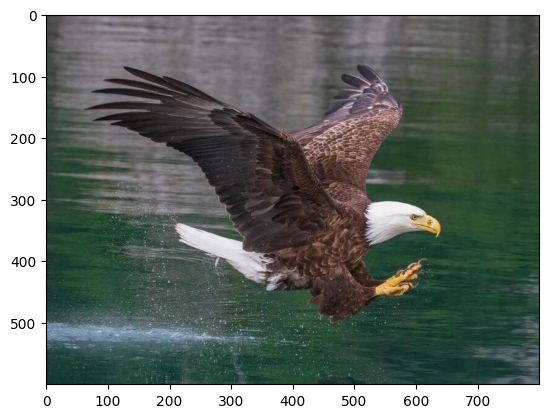

In [2]:
img_path = "D:\myself\IPEM\data\\animals\eagle\\0df14cf243.jpg"

img = Image.open(img_path)
plt.imshow(img)

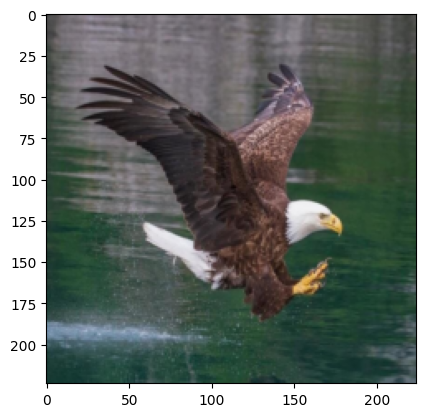

In [3]:
# Transform image to 224x224
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
img_tensor = transform(img)
# Show image
plt.imshow(img_tensor.permute(1, 2, 0))
plt.show()


In [4]:
current_dir = os.getcwd()
print(current_dir)
parent_dir = os.path.dirname(current_dir)
os.chdir(parent_dir)

animals_clf = AnimalImageClassifier(data_dir="D:\myself\IPEM\data", args_model="efficientnet_b3")
animals_clf.load_trained_model()


d:\myself\IPEM\src
outputs\animals\efficientnet_b3_best_model.pt


In [5]:
ipem = IPEMExplainer(animals_clf.model, class_names=animals_clf.class_names)

import numpy as np
import cv2
from skimage.segmentation import slic, watershed
from skimage.filters import sobel


def _build_watershed_segments(
    img_segment: np.ndarray,
    n_markers: int = 100,
    compactness: float = 0.001,
    sigma: float = 1.0
) -> np.ndarray:
    H, W = img_segment.shape[:2]

    if img_segment.ndim == 3 and img_segment.shape[2] >= 3:
        gray = cv2.cvtColor((img_segment * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
        gray = gray.astype(np.float32) / 255.0
    elif img_segment.ndim == 3:
        gray = img_segment[..., 0]
    else:
        gray = img_segment

    if sigma > 0:
        gray = cv2.GaussianBlur(gray, (0, 0), sigmaX=sigma)

    gradient = sobel(gray)

    n_markers = max(4, int(n_markers))
    marker_rows = max(2, int(np.sqrt(n_markers * H / max(W, 1))))
    marker_cols = max(2, int(np.ceil(n_markers / marker_rows)))

    ys = np.linspace(0, H - 1, marker_rows, dtype=np.int32)
    xs = np.linspace(0, W - 1, marker_cols, dtype=np.int32)

    markers = np.zeros((H, W), dtype=np.int32)
    label = 1
    for y in ys:
        for x in xs:
            markers[y, x] = label
            label += 1

    segments = watershed(
        gradient,
        markers=markers,
        compactness=compactness,
    )

    return segments.astype(np.int64) - 1

In [7]:
from pathlib import Path
import torch

resized_img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
segments = _build_watershed_segments(resized_img_np, n_markers=100, compactness=0.001, sigma=1.0)

segments_t = torch.from_numpy(segments).long().to(img_tensor.device)
K = int(segments.max()) + 1
n_samples = 3
mask_prob = 0.5

masks_sp = (torch.rand(n_samples, K, device=img_tensor.device) < mask_prob).float()
empty_rows = masks_sp.sum(dim=1) == 0
if empty_rows.any():
    rand_idx = torch.randint(0, K, (empty_rows.sum().item(),), device=img_tensor.device)
    masks_sp[empty_rows, rand_idx] = 1.0

pixel_masks = masks_sp[:, segments_t].unsqueeze(1)
perturbed_imgs = img_tensor.unsqueeze(0) * pixel_masks

tmp_dir = Path("tmp")
tmp_dir.mkdir(parents=True, exist_ok=True)
to_pil = transforms.ToPILImage()

for idx in range(n_samples):
    mask_img = (pixel_masks[idx].squeeze(0).detach().cpu().numpy() * 255).astype(np.uint8)
    Image.fromarray(mask_img, mode="L").save(tmp_dir / f"mask_{idx + 1}.png")

    perturbed_img = perturbed_imgs[idx].detach().cpu().clamp(0, 1)
    to_pil(perturbed_img).save(tmp_dir / f"perturbed_{idx + 1}.png")

print(f"Da luu 6 anh vao: {tmp_dir.resolve()}")
print([p.name for p in sorted(tmp_dir.iterdir())])

Da luu 6 anh vao: D:\myself\IPEM\tmp
['mask_1.png', 'mask_2.png', 'mask_3.png', 'perturbed_1.png', 'perturbed_2.png', 'perturbed_3.png']


In [ ]:
from skimage.util import img_as_float
import torch

def _prepare_image_for_segmentation(img_tensor: torch.Tensor) -> np.ndarray:
    img_np = img_tensor.detach().cpu().float().numpy().transpose(1, 2, 0)
    img_min = img_np.min()
    img_max = img_np.max()
    img_np = (img_np - img_min) / (img_max - img_min + 1e-8)
    return img_as_float(img_np)

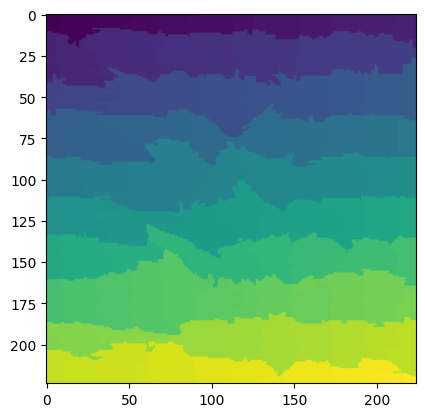

In [ ]:
img_segment = _prepare_image_for_segmentation(img_tensor)
segments = _build_watershed_segments(
                img_segment,
                n_markers=120,
                compactness=0.001,
                sigma=1.0
            )

plt.imshow(segments)
plt.show()

In [ ]:
# segments_t = torch.from_numpy(segments).to(self.device)
# masks_sp = (torch.rand(n_samples, K, device=self.device) < mask_prob).float()

# empty_rows = masks_sp.sum(dim=1) == 0
# if empty_rows.any():
#     rand_idx = torch.randint(0, K, (empty_rows.sum().item(),), device=self.device)
#     masks_sp[empty_rows, rand_idx] = 1.0

# pixel_masks = masks_sp[:, segments_t].unsqueeze(1)
# perturbed_imgs = img.unsqueeze(0) * pixel_masks